# Sentinel-2 Random 10x10 km Image Fetcher

Boilerplate notebook for pulling a 10x10 km true-color image at a random
location using the **Copernicus Data Space Ecosystem (CDSE)** via the
`sentinelhub-py` package.

**Setup required before running:**
1. Create a free account at https://dataspace.copernicus.eu/
2. Go to your Dashboard -> "OAuth clients" and create a new client to get a
   `CLIENT_ID` and `CLIENT_SECRET`.
3. `pip install sentinelhub matplotlib numpy`


In [6]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

from sentinelhub import (
    SHConfig,
    CRS,
    BBox,
    bbox_to_dimensions,
    SentinelHubRequest,
    DataCollection,
    MimeType,
)

## 1. Configure credentials

Fill in your CDSE OAuth client ID/secret below (or better: set them as
environment variables `SH_CLIENT_ID` / `SH_CLIENT_SECRET` and load with
`os.environ`).

In [7]:
from dotenv import load_dotenv
import os

load_dotenv()
config = SHConfig()
config.sh_client_id = os.environ.get("SH_CLIENT_ID")
config.sh_client_secret = os.environ.get("SH_CLIENT_SECRET")

if not config.sh_client_id or not config.sh_client_secret:
    raise ValueError("Set SH_CLIENT_ID / SH_CLIENT_SECRET in your .env file or environment.")

# CDSE runs its own Sentinel Hub deployment: both the service endpoint and the
# OAuth token endpoint differ from the sentinelhub-py defaults
# (services.sentinel-hub.com), so point the config at CDSE explicitly.
# See https://sentinelhub-py.readthedocs.io/en/latest/configure.html
CDSE_BASE_URL = "https://sh.dataspace.copernicus.eu"
config.sh_base_url = CDSE_BASE_URL
config.sh_token_url = (
    "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/"
    "protocol/openid-connect/token"
)

## 2. Pick a random location and build a 10x10 km bounding box

We pick a random latitude/longitude (you can constrain the ranges to avoid
oceans/poles), then convert a 10 km x 10 km square centered on that point
into a `BBox`.

In [8]:
def bbox_from_center(lat, lon, size_km=10):
    """Build a size_km x size_km BBox (in degrees, EPSG:4326) centered on (lat, lon)."""
    half_km = size_km / 2
    # ~111.32 km per degree latitude
    dlat = half_km / 111.32
    # longitude degrees shrink with latitude
    dlon = half_km / (111.32 * math.cos(math.radians(lat)))

    min_lon, max_lon = lon - dlon, lon + dlon
    min_lat, max_lat = lat - dlat, lat + dlat

    return BBox(bbox=[min_lon, min_lat, max_lon, max_lat], crs=CRS.WGS84)


lat, lon = 36.149568, 74.856459

bbox = bbox_from_center(lat, lon, size_km=15)
resolution = 10  # meters/pixel (native Sentinel-2 resolution for RGB bands)
size = bbox_to_dimensions(bbox, resolution=resolution)

print(f"Random location: lat={lat:.5f}, lon={lon:.5f}")
print(f"BBox: {bbox}")
print(f"Image size (px): {size}")


Random location: lat=36.14957, lon=74.85646
BBox: 74.77302244383542,36.082194661875675,74.93989555616459,36.21694133812433
Image size (px): (1503, 1492)


/var/folders/tv/012wfz9x0g79ynsktt7g58k40000gn/T/ipykernel_21294/3407866141.py:22: SHDeprecationWarning: The string representation of `BBox` will change to match its `repr` representation.
  print(f"BBox: {bbox}")


## 3. Request one NIR image per month (least cloud cover)

For glacier movement via optical feature tracking, **Band 8 (NIR, 10 m)**
is the standard choice — it gives the strongest contrast on crevasses,
ogives, and surface debris patterns you'd track between dates. We pull a
single grayscale NIR image for each calendar month (least-cloud mosaic),
so you end up with a time series you can feed into a cross-correlation /
feature-tracking tool (e.g. autoRIFT, ImGRAFT).

If you swap in a different collection (e.g. `SENTINEL2_L1C`), remember to
also call `.define_from(..., service_url=config.sh_base_url)` on it, same
as below — otherwise it'll quietly point at the wrong Sentinel Hub
deployment.

In [9]:
print(repr(config.sh_client_id))
print(repr(config.sh_base_url))

'sh-3d267cff-512e-45ed-9b6f-b33a8c7c2391'
'https://sh.dataspace.copernicus.eu'


In [10]:
# IMPORTANT: DataCollection.SENTINEL2_L2A is hardwired to
# services.sentinel-hub.com, so we derive a copy that points at the CDSE
# deployment configured above — otherwise requests 401 against the wrong
# service.
if config.sh_base_url.rstrip("/") != CDSE_BASE_URL:
    raise ValueError(
        f"config.sh_base_url is {config.sh_base_url!r}, expected {CDSE_BASE_URL!r}"
        " — run the config cell first."
    )

# `define_from` registers a NEW collection and raises ValueError if a
# collection with exactly this definition already exists (which is what happens
# when the cell is re-run in the same kernel, or when sh_base_url still holds
# the default URL). Look the collection up first and only derive it once.
try:
    cdse_s2l2a = DataCollection["cdse_s2l2a"]
except KeyError:
    cdse_s2l2a = DataCollection.SENTINEL2_L2A.define_from(
        "cdse_s2l2a", service_url=CDSE_BASE_URL
    )

# Single-band NIR (B08) evalscript — best surface-feature contrast for
# glacier crevasses/ogives/debris used in offset/feature tracking.
evalscript_nir = """
//VERSION=3
function setup() {
    return {
        input: [{ bands: ["B08"] }],
        output: { bands: 1, sampleType: "UINT8" }
    };
}

function evaluatePixel(sample) {
    return [sample.B08 * 255];
}
"""

import calendar

YEAR = 2024
monthly_images = {}  # month (1-12) -> (image array, (start_date, end_date))

for month in range(1, 13):
    start = f"{YEAR}-{month:02d}-01"
    last_day = calendar.monthrange(YEAR, month)[1]
    end = f"{YEAR}-{month:02d}-{last_day:02d}"

    request = SentinelHubRequest(
        evalscript=evalscript_nir,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=cdse_s2l2a,
                time_interval=(start, end),
                mosaicking_order="leastCC",  # least cloud coverage
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.PNG)],
        bbox=bbox,
        size=size,
        config=config,
    )

    img = request.get_data()[0]
    monthly_images[month] = (img, (start, end))
    print(f"{calendar.month_name[month]}: shape={img.shape}, mean={img.mean():.1f}")

    output_dir = "sentinel2_nir_monthly"
    os.makedirs(output_dir, exist_ok=True)

    filename = os.path.join(output_dir, f"{YEAR}_{month:02d}_{calendar.month_name[month]}.png")
    plt.imsave(filename, img.squeeze(), cmap="gray", vmin=0, vmax=255)
    print(f"Saved: {filename}")


January: shape=(1492, 1503), mean=85.4
Saved: sentinel2_nir_monthly/2024_01_January.png
February: shape=(1492, 1503), mean=113.6
Saved: sentinel2_nir_monthly/2024_02_February.png
March: shape=(1492, 1503), mean=151.2
Saved: sentinel2_nir_monthly/2024_03_March.png
April: shape=(1492, 1503), mean=139.8
Saved: sentinel2_nir_monthly/2024_04_April.png
May: shape=(1492, 1503), mean=116.4
Saved: sentinel2_nir_monthly/2024_05_May.png
June: shape=(1492, 1503), mean=82.6
Saved: sentinel2_nir_monthly/2024_06_June.png
July: shape=(1492, 1503), mean=72.4
Saved: sentinel2_nir_monthly/2024_07_July.png
August: shape=(1492, 1503), mean=63.2
Saved: sentinel2_nir_monthly/2024_08_August.png
September: shape=(1492, 1503), mean=60.2
Saved: sentinel2_nir_monthly/2024_09_September.png
October: shape=(1492, 1503), mean=71.0
Saved: sentinel2_nir_monthly/2024_10_October.png
November: shape=(1492, 1503), mean=93.7
Saved: sentinel2_nir_monthly/2024_11_November.png
December: shape=(1492, 1503), mean=103.8
Saved: se

## 4. Display the monthly image grid

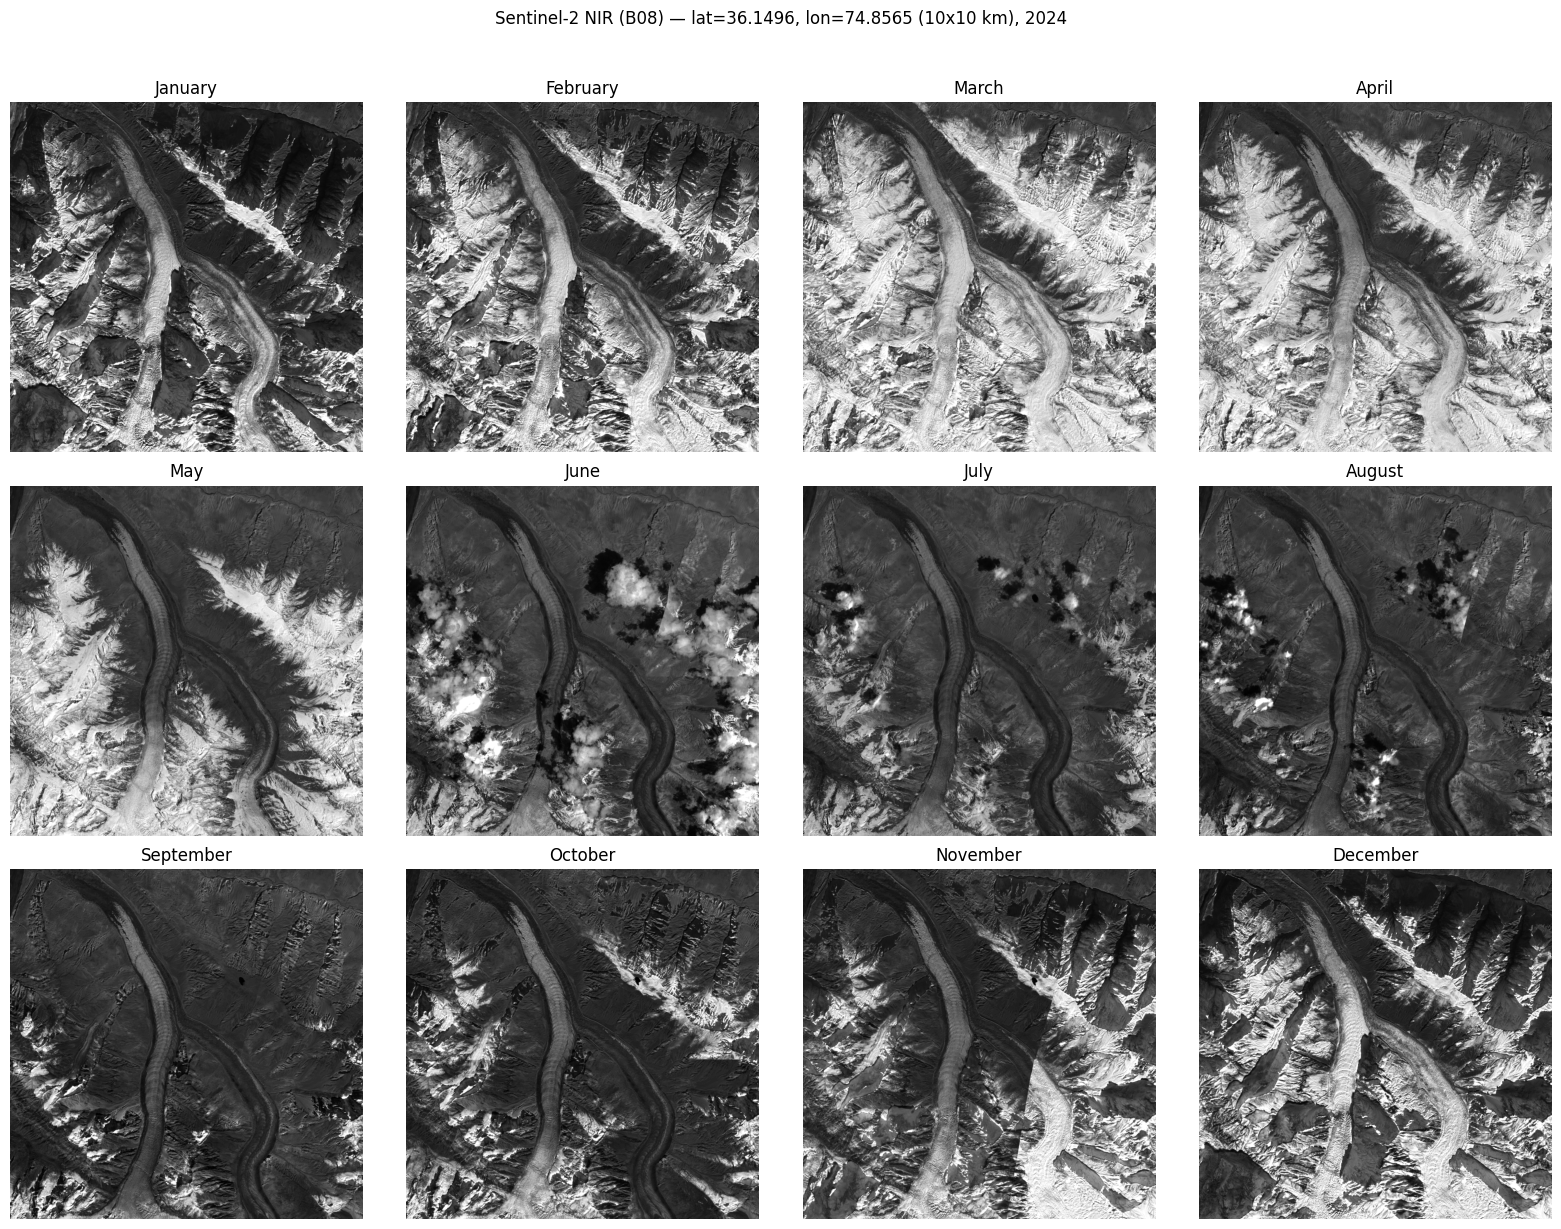

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for month in range(1, 13):
    ax = axes[(month - 1) // 4, (month - 1) % 4]
    img, (start, end) = monthly_images[month]
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=255)
    ax.set_title(calendar.month_name[month])
    ax.axis("off")

fig.suptitle(f"Sentinel-2 NIR (B08) — lat={lat:.4f}, lon={lon:.4f} (10x10 km), {YEAR}", y=1.02)
plt.tight_layout()
plt.show()
